 # Whisper Accent Robustness — Model Performance Evaluation



 Run `eval_model_perf.py` on SLURM first to generate the CSVs this notebook reads.



 - **Scripted**     → 6 held-out test speakers (never seen during training)

 - **Spontaneous**  → suitcase corpus (OOD, all speakers)



 Metrics:

 - **WER**  — word error rate (primary ASR metric)

 - **PER**  — phoneme error rate via G2P; labelled "PER (G2P)" throughout

In [1]:
# ── Config ────────────────────────────────────────────────────────────────────
RESULTS_DIR = "results/model_perf_comparison"

# Keys must match {model_key} in CSV filenames; values are display labels
MODEL_KEYS = {
    "baseline":      "Zero-shot",
    # "baseline_lora": "Naive LoRA FT",
    "no_aux":        "Naive LoRA FT",
    # "no_aux_heldout_chinese":        "Naive LoRA FT (heldout Chinese)",
    # "ctc_aux_l3":    "CTC Aux",
    "feat_aux":      "Feat Aux",
    # "feat_aux_heldout_chinese":      "Feat Aux (heldout Chinese)",
    "feat_aux0p3":      "Feat Aux (0.3)",
    # "both_aux":      "CTC + Feat",
}
SPLITS = ["scripted", "spontaneous"]


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display
from jiwer import wer as jiwer_wer

pd.set_option("display.max_colwidth", 80)


In [3]:
def load_results(model_key: str, split: str) -> pd.DataFrame | None:
    p = Path(RESULTS_DIR) / f"{model_key}_{split}_predictions.csv"
    if not p.exists():
        print(f"  [missing] {p} — run eval_model_perf.py first")
        return None
    return pd.read_csv(p)

# ── Load all cached CSVs ──────────────────────────────────────────────────────
results: dict[str, dict[str, pd.DataFrame | None]] = {}
for key in MODEL_KEYS:
    results[key] = {}
    for split in SPLITS:
        df = load_results(key, split)
        results[key][split] = df
        if df is not None:
            print(f"  loaded  {key}/{split}: {len(df):,} rows")


  loaded  baseline/scripted: 7,638 rows
  loaded  baseline/spontaneous: 441 rows
  loaded  no_aux/scripted: 7,638 rows
  loaded  no_aux/spontaneous: 441 rows
  loaded  feat_aux/scripted: 7,638 rows
  loaded  feat_aux/spontaneous: 441 rows
  loaded  feat_aux0p3/scripted: 7,638 rows
  loaded  feat_aux0p3/spontaneous: 441 rows


In [4]:
# ── Helpers ──────────────────────────────────────────────────────────────────


def available(key: str, split: str) -> bool:
    return results.get(key, {}).get(split) is not None


def corpus_wer(df: pd.DataFrame) -> float:
    return float(jiwer_wer(
        df["reference_norm"].fillna("").tolist(),
        df["prediction_norm"].fillna("").tolist(),
    ))


def corpus_per(df: pd.DataFrame) -> float | None:
    """Mean utterance PER (G2P-derived), precomputed by eval_model_perf.py."""
    if "utt_per" not in df.columns:
        return None
    vals = df["utt_per"].dropna()
    return float(vals.mean()) if len(vals) else None


def grouped_wer(df: pd.DataFrame, group_col: str = "l1") -> pd.DataFrame:
    rows = []
    for grp, sub in df.groupby(group_col):
        rows.append({
            group_col:  grp,
            "num_utts": len(sub),
            "wer":      float(jiwer_wer(
                            sub["reference_norm"].fillna("").tolist(),
                            sub["prediction_norm"].fillna("").tolist(),
                        )),
            "per":      float(sub["utt_per"].dropna().mean())
                        if "utt_per" in sub.columns else None,
        })
    return pd.DataFrame(rows)


print("Helpers loaded.")


Helpers loaded.


 ---

 # Part 1 — Overall WER & PER (G2P)

In [5]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for key, label in MODEL_KEYS.items():
    for split in SPLITS:
        if not available(key, split):
            continue
        df  = results[key][split]
        wer = corpus_wer(df)
        per = corpus_per(df)
        rows.append({"Model": label, "Split": split, "WER": wer, "PER (G2P)": per})

overall_df = pd.DataFrame(rows)

for metric in ["WER", "PER (G2P)"]:
    pivot = overall_df.pivot(index="Model", columns="Split", values=metric)
    display(
        pivot.style
             .format("{:.4f}")
             .background_gradient(cmap="RdYlGn_r", axis=0)
             .set_caption(f"{metric} by Model × Split (lower is better)")
    )


Split,scripted,spontaneous
Model,,
Feat Aux,0.0699,0.2758
Feat Aux (0.3),0.0759,0.2633
Naive LoRA FT,0.0731,0.2579
Zero-shot,0.1625,0.1979


Split,scripted,spontaneous
Model,,
Feat Aux,0.0436,0.2865
Feat Aux (0.3),0.0497,0.2668
Naive LoRA FT,0.0452,0.2686
Zero-shot,0.0871,0.1892


In [6]:
from plotly.subplots import make_subplots

# ── Separate WER/PER into side-by-side subplots, one figure per split ─────────

for split in SPLITS:
    sub = overall_df[overall_df["Split"] == split].copy()
    if sub.empty:
        continue

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("WER", "PER (G2P)"),
        shared_yaxes=True,
    )

    # Left: WER
    wer_vals = sub["WER"]
    fig.add_trace(
        go.Bar(
            name="WER",
            x=sub["Model"].tolist(),
            y=wer_vals.tolist(),
            text=[f"{v:.1%}" if pd.notna(v) else "" for v in wer_vals],
            textposition="outside",
            showlegend=False,
        ),
        row=1, col=1
    )

    # Right: PER
    per_vals = sub["PER (G2P)"]
    if per_vals.notna().any():
        fig.add_trace(
            go.Bar(
                name="PER (G2P)",
                x=sub["Model"].tolist(),
                y=per_vals.tolist(),
                text=[f"{v:.1%}" if pd.notna(v) else "" for v in per_vals],
                textposition="outside",
                showlegend=False,
            ),
            row=1, col=2
        )

    fig.update_yaxes(title_text="Error Rate", tickformat=".0%", row=1, col=1)
    fig.update_yaxes(tickformat=".0%", row=1, col=2)
    fig.update_layout(
        title=f"WER vs PER by Model — {split.capitalize()}",
        margin=dict(t=90),
    )
    fig.show()


 ---

 # Part 2 — Per-L1 WER

In [7]:
for split in SPLITS:
    l1_rows = []
    for key, label in MODEL_KEYS.items():
        if not available(key, split):
            continue
        grp = grouped_wer(results[key][split], "l1")
        grp["Model"] = label
        l1_rows.append(grp)
    if not l1_rows:
        continue

    l1_df = pd.concat(l1_rows, ignore_index=True)

    # Delta vs zero-shot baseline (negative = improvement)
    base_label = MODEL_KEYS["no_aux"]
    base_wer   = (
        l1_df[l1_df["Model"] == base_label][["l1", "wer"]]
        .rename(columns={"wer": "wer_base"})
    )
    l1_df = l1_df.merge(base_wer, on="l1", how="left")
    l1_df["wer_delta_pct"] = (
        (l1_df["wer"] - l1_df["wer_base"]) / l1_df["wer_base"] * 100
    )

    l1s = sorted(l1_df["l1"].unique())

    fig = go.Figure()
    for key, label in MODEL_KEYS.items():
        sub = l1_df[l1_df["Model"] == label].set_index("l1")
        fig.add_trace(go.Bar(
            name = label,
            x    = l1s,
            y    = [sub.loc[l, "wer"] if l in sub.index else None for l in l1s],
            text = [f"{sub.loc[l, 'wer']:.1%}" if l in sub.index else "" for l in l1s],
            textposition = "outside",
        ))
    fig.update_layout(
        title   = f"WER by L1 — {split.capitalize()}",
        barmode = "group",
        yaxis   = dict(title="WER", tickformat=".0%"),
        legend  = dict(orientation="h", y=1.12, xanchor="center", x=0.5),
        margin  = dict(t=80),
    )
    fig.show()

    out = Path(RESULTS_DIR) / f"comparison_{split}_by_l1.csv"
    l1_df.to_csv(out, index=False)
    print(f"Saved {out}")
    display(
        l1_df.sort_values(["l1", "Model"])
             .style.format({
                 "wer":           "{:.4f}",
                 "wer_base":      "{:.4f}",
                 "wer_delta_pct": "{:+.1f}%",
                 "per":           lambda v: f"{v:.4f}" if pd.notna(v) else "—",
             })
             .set_caption(f"{split.capitalize()} — Per-L1 WER")
    )


Saved results/model_perf_comparison/comparison_scripted_by_l1.csv


,l1,num_utts,wer,per,Model,wer_base,wer_delta_pct
14,Arabic,974,0.1048,0.0679,Feat Aux,0.1084,-3.3%
21,Arabic,974,0.1546,0.1230,Feat Aux (0.3),0.1084,+42.6%
7,Arabic,974,0.1084,0.0718,Naive LoRA FT,0.1084,+0.0%
0,Arabic,974,0.2388,0.1375,Zero-shot,0.1084,+120.4%
15,Chinese,1130,0.0846,0.0530,Feat Aux,0.0910,-7.1%
22,Chinese,1130,0.0895,0.0543,Feat Aux (0.3),0.0910,-1.6%
8,Chinese,1130,0.0910,0.0543,Naive LoRA FT,0.0910,+0.0%
1,Chinese,1130,0.1916,0.1060,Zero-shot,0.0910,+110.4%
16,English,1132,0.0196,0.0067,Feat Aux,0.0198,-1.0%
23,English,1132,0.0187,0.0066,Feat Aux (0.3),0.0198,-5.6%


Saved results/model_perf_comparison/comparison_spontaneous_by_l1.csv


,l1,num_utts,wer,per,Model,wer_base,wer_delta_pct
16,Arabic,3,0.1399,0.0776,Feat Aux,0.1554,-10.0%
24,Arabic,3,0.1347,0.0744,Feat Aux (0.3),0.1554,-13.3%
8,Arabic,3,0.1554,0.0885,Naive LoRA FT,0.1554,+0.0%
0,Arabic,3,0.1192,0.0663,Zero-shot,0.1554,-23.3%
17,Chinese,4,0.2336,0.1128,Feat Aux,0.2190,+6.7%
25,Chinese,4,0.2318,0.1185,Feat Aux (0.3),0.2190,+5.8%
9,Chinese,4,0.2190,0.1135,Naive LoRA FT,0.2190,+0.0%
1,Chinese,4,0.2135,0.1153,Zero-shot,0.2190,-2.5%
18,English,184,0.3122,0.2884,Feat Aux,0.1972,+58.3%
26,English,184,0.3189,0.2910,Feat Aux (0.3),0.1972,+61.7%


 ---

 # Part 3 — Scripted vs Spontaneous Gap (zero-shot)



 Different corpora → compared at L1 level, not speaker level.

In [8]:
if available("baseline", "scripted") and available("baseline", "spontaneous"):
    s_g  = grouped_wer(results["baseline"]["scripted"],    "l1").rename(columns={"wer": "WER_scripted"})
    sp_g = grouped_wer(results["baseline"]["spontaneous"], "l1").rename(columns={"wer": "WER_spontaneous"})
    gap  = s_g[["l1", "WER_scripted"]].merge(
               sp_g[["l1", "WER_spontaneous"]], on="l1", how="inner")
    gap["gap"] = gap["WER_spontaneous"] - gap["WER_scripted"]

    l1s = gap["l1"].tolist()
    fig = go.Figure()
    fig.add_trace(go.Bar(name="Scripted",    x=l1s, y=gap["WER_scripted"].tolist()))
    fig.add_trace(go.Bar(name="Spontaneous", x=l1s, y=gap["WER_spontaneous"].tolist()))
    fig.update_layout(
        title   = "Zero-shot WER — Scripted vs Spontaneous by L1",
        barmode = "group",
        yaxis   = dict(title="WER", tickformat=".0%"),
        legend  = dict(orientation="h", y=1.12, xanchor="center", x=0.5),
    )
    fig.show()
    display(
        gap.style
           .format({c: "{:.4f}" for c in ["WER_scripted", "WER_spontaneous", "gap"]})
           .set_caption("Scripted vs Spontaneous WER gap (zero-shot)")
    )


,l1,WER_scripted,WER_spontaneous,gap
0,Arabic,0.2388,0.1192,-0.1196
1,Chinese,0.1916,0.2135,0.0219
2,English,0.0382,0.1688,0.1307
3,Hindi,0.0653,0.1026,0.0373
4,Korean,0.0805,0.1553,0.0748
5,Spanish,0.2284,0.0967,-0.1317
6,Vietnamese,0.3117,0.2287,-0.0830


 ---

 # Part 4 — Utterance-level Analysis

In [9]:
# ── UTT WER distributions ─────────────────────────────────────────────────────
fig = go.Figure()
key = "feat_aux"
label = MODEL_KEYS[key]
split = "scripted"
fig.add_trace(go.Histogram(
    x       = results[key][split]["utt_wer"],
    name    = f"{label} / {split}",
    opacity = 0.5,
    nbinsx  = 40,
))
fig.update_layout(
    title    = "Utterance WER Distribution — All Conditions",
    barmode  = "overlay",
    xaxis    = dict(title="Utterance WER"),
    yaxis    = dict(title="Count"),
    legend   = dict(orientation="h", y=1.12, xanchor="center", x=0.5),
)
fig.show()


In [10]:
# ── Worst utterances per model — scripted, cross-model comparison ─────────────
split    = "spontaneous"
N_WORST  = 15
models = [
    "baseline",
    "no_aux",
    "feat_aux0p3",
]
base_df = results["no_aux"][split]

for anchor_key in models:
    if not available(anchor_key, split):
        continue

    anchor_df = results[anchor_key][split]
    idx       = anchor_df.nlargest(N_WORST, "utt_wer").index

    worst = base_df.loc[idx, ["utterance_id", "speaker", "l1", "reference_norm"]].copy()

    # Add each model's prediction + WER + PER for these utterances
    for key in models:
        if not available(key, split):
            continue
        other            = results[key][split]
        col              = key
        worst[f"pred_{col}"] = other.loc[idx, "prediction_norm"].values
        worst[f"wer_{col}"]  = other.loc[idx, "utt_wer"].values
        if "utt_per" in other.columns:
            worst[f"per_{col}"] = other.loc[idx, "utt_per"].values

    fmt_cols = {c: "{:.3f}" for c in worst.columns if c.startswith(("wer_", "per_"))}
    display(
        worst.style
                .format(fmt_cols)
                .set_caption(f"Top-{N_WORST} Worst Utterances for {MODEL_KEYS[anchor_key]} — {split.capitalize()}")
    )

,utterance_id,speaker,l1,reference_norm,pred_baseline,wer_baseline,per_baseline,pred_no_aux,wer_no_aux,per_no_aux,pred_feat_aux0p3,wer_feat_aux0p3,per_feat_aux0p3
111,EDACC-C49-000000062,EDACC-C49-B,Jamaican,thats like a zombie,thats all i got to say,1.250,0.615,thats like a song,0.250,0.385,thats why i got some,1.000,0.615
203,EDACC-C49-000000204,EDACC-C49-B,Jamaican,probably i am i probably am,no problem,1.000,0.727,probably ah ah,0.833,0.591,probably ah ah,0.833,0.591
208,EDACC-C49-000000210,EDACC-C49-B,Jamaican,three hundred dollars thats a,he on the eyes,1.000,0.800,hes on his eyes,1.000,0.850,fear on you always im sorry,1.200,0.950
223,EDACC-C49-000000229,EDACC-C49-A,Jamaican,cause its just grease,this is just a dream,1.000,0.571,its just green,0.500,0.286,its just grease,0.250,0.214
226,EDACC-C49-000000234,EDACC-C49-B,Jamaican,i dont really eat pizza that,are you,1.000,0.895,how are you,1.000,0.895,are you serious you idiot,1.000,0.842
272,EDACC-C03-000000043,EDACC-C03-B,English,hmm what what were you going to say,mmhmm,1.000,0.905,youre going to say,0.625,0.619,hmm o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o,55.375,21.048
300,EDACC-C06-000000000,EDACC-C06-A,English,c eleven dash p one,c11p1,1.000,0.500,c11 dash p1,0.800,0.375,c eleven dash p one,0.000,0.000
346,EDACC-C06-000000116,EDACC-C06-A,English,i just lose it,and the sound,1.000,1.000,i just mean to say,0.750,0.700,and the sound,1.000,1.000
237,EDACC-C49-000000251,EDACC-C49-A,Jamaican,yeah the food was o laugh the food was like trash but,but,0.917,0.906,the food was all over the food was like trash,0.333,0.281,the food was all the food was like trash,0.333,0.250
69,EDACC-C48-000000089,EDACC-C48-A,Jamaican,yeah they decided they wanted to stop it,yeah that is an error in the subject,0.875,0.704,yea that is an irate subject,1.000,0.741,yea that is an irate subject,1.000,0.741


,utterance_id,speaker,l1,reference_norm,pred_baseline,wer_baseline,per_baseline,pred_no_aux,wer_no_aux,per_no_aux,pred_feat_aux0p3,wer_feat_aux0p3,per_feat_aux0p3
94,EDACC-C49-000000031,EDACC-C49-A,Jamaican,nah its not cold one thing though that i miss about being home like i cant wait to go back home in september is like the,one thing though that i miss is like,0.692,0.737,and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened and then all that stuff happened,17.038,20.000,in the basel one thing do that i miss about being home like i cant wait to go back home in september is like the,0.192,0.158
278,EDACC-C03-000000061,EDACC-C03-B,English,rotating circular thing icon,rotating circular icon,0.250,0.143,we were taking exactly the open icon,1.500,0.857,were taking exactly the same icon,1.250,0.714
202,EDACC-C49-000000203,EDACC-C49-A,Jamaican,you gotta be tripping,you gotta be sure,0.250,0.429,youve got to be sure phil,1.250,0.571,youve got to be sure phil,1.250,0.571
143,EDACC-C49-000000110,EDACC-C49-B,Jamaican,its like july the eighteenth so,by the riser team,0.833,0.789,id buy the right for a fee so,1.167,0.737,id buy the right for a few more,1.333,0.947
33,EDACC-C48-000000022,EDACC-C48-A,Jamaican,yeah i think,yeah i think i,0.333,0.143,yea i think i think,1.000,0.857,yea i think i,0.667,0.286
69,EDACC-C48-000000089,EDACC-C48-A,Jamaican,yeah they decided they wanted to stop it,yeah that is an error in the subject,0.875,0.704,yea that is an irate subject,1.000,0.741,yea that is an irate subject,1.000,0.741
104,EDACC-C49-000000054,EDACC-C49-B,Jamaican,its really fun though,really fun,0.500,0.417,the fairly summed down,1.

,utterance_id,speaker,l1,reference_norm,pred_baseline,wer_baseline,per_baseline,pred_no_aux,wer_no_aux,per_no_aux,pred_feat_aux0p3,wer_feat_aux0p3,per_feat_aux0p3
272,EDACC-C03-000000043,EDACC-C03-B,English,hmm what what were you going to say,mmhmm,1.000,0.905,youre going to say,0.625,0.619,hmm o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o o,55.375,21.048
143,EDACC-C49-000000110,EDACC-C49-B,Jamaican,its like july the eighteenth so,by the riser team,0.833,0.789,id buy the right for a fee so,1.167,0.737,id buy the right for a few more,1.333,0.947
202,EDACC-C49-000000203,EDACC-C49-A,Jamaican,you gotta be tripping,you gotta be sure,0.250,0.429,youve got to be sure phil,1.250,0.571,youve got to be sure phil,1.250,0.571
278,EDACC-C03-000000061,EDACC-C03-B,English,rotating circular thing icon,rotating circular icon,0.250,0.143,we were taking exactly the open icon,1.500,0.857,were taking exactly the same icon,1.250,0.714
378,EDACC-C43_P1-000000045,EDACC-C43-B,English,yeah hakes hakes okay,yeah hakes hakes okay,0.000,0.000,yea hee hee hee,1.000,0.769,yea hei hei hei hei,1.250,0.769
208,EDACC-C49-000000210,EDACC-C49-B,Jamaican,three hundred dollars thats a,he on the eyes,1.000,0.800,hes on his eyes,1.000,0.850,fear on you always im sorry,1.200,0.950
69,EDACC-C48-000000089,EDACC-C48-A,Jamaican,yeah they decided they wanted to stop it,yeah that is an error in the subject,0.875,0.704,yea that is an irate subject,1.000,0.741,yea that is an irate subject,1.000,0.741
105,EDACC-C49-000000055,EDACC-C49-A,Jamaican,good like i probably should watch that,like i probably should have said,0.429,0.375,like ive got to say myself,0.857,0.792,like ive copies of you i said,1.000,0.750
111,EDACC-C49-000000062,EDACC-C49-B,Jamaican,thats like a zombie,thats all i got to say,1.250,0.615,thats like a song,0.250,0.385,thats why i got some,1.000,0.615
156,EDACC-C49-000000131,EDACC-C49-A,Jamaican,youd like to go where,youre going to go where,0.400,0.462,you dancing over it,1.000,0.846,you dancing away,1.000,0.769


In [11]:
# ── Utterance-level head-to-head win counts ───────────────────────────────────
split = "scripted"   # change to "spontaneous" if needed

available_keys = [k for k in MODEL_KEYS if available(k, split)]

for anchor_key in models:
    anchor_label = MODEL_KEYS[anchor_key]
    anchor_wer   = results[anchor_key][split]["utt_wer"].fillna(1.0)
    n_utts       = len(anchor_wer)

    print(f"\n{anchor_label} vs others ({split}, n={n_utts} utterances):")
    for other_key in models:
        if other_key == anchor_key:
            continue
        other_wer  = results[other_key][split]["utt_wer"].fillna(1.0)
        anchor_label_short = MODEL_KEYS[other_key]

        wins  = (anchor_wer < other_wer).sum()
        ties  = (anchor_wer == other_wer).sum()
        loses = (anchor_wer > other_wer).sum()

        print(f"  vs {anchor_label_short:<20} | "
              f"wins={wins:>4} ({wins/n_utts:.1%})  "
              f"ties={ties:>4} ({ties/n_utts:.1%})  "
              f"loses={loses:>4} ({loses/n_utts:.1%})")


Zero-shot vs others (scripted, n=7638 utterances):
  vs Naive LoRA FT        | wins= 392 (5.1%)  ties=3847 (50.4%)  loses=3399 (44.5%)
  vs Feat Aux (0.3)       | wins= 373 (4.9%)  ties=3808 (49.9%)  loses=3457 (45.3%)

Naive LoRA FT vs others (scripted, n=7638 utterances):
  vs Zero-shot            | wins=3399 (44.5%)  ties=3847 (50.4%)  loses= 392 (5.1%)
  vs Feat Aux (0.3)       | wins= 583 (7.6%)  ties=6313 (82.7%)  loses= 742 (9.7%)

Feat Aux (0.3) vs others (scripted, n=7638 utterances):
  vs Zero-shot            | wins=3457 (45.3%)  ties=3808 (49.9%)  loses= 373 (4.9%)
  vs Naive LoRA FT        | wins= 742 (9.7%)  ties=6313 (82.7%)  loses= 583 (7.6%)


# Held-out L1 Performance - Accent-Robustness

output/heldout_l1_comparison.csv
output/heldout_l1_points_whiskers.png


,model_key,model,n_utts,n_speakers,wer_mean,per_mean,per_std
0,baseline,Zero-shot,184,3,16.881,0.147,0.165
1,no_aux,Naive LoRA FT,184,3,19.721,0.185,0.186
2,feat_aux,Feat Aux,184,3,31.217,0.288,1.546
3,feat_aux0p3,Feat Aux (0.3),184,3,31.886,0.291,1.548


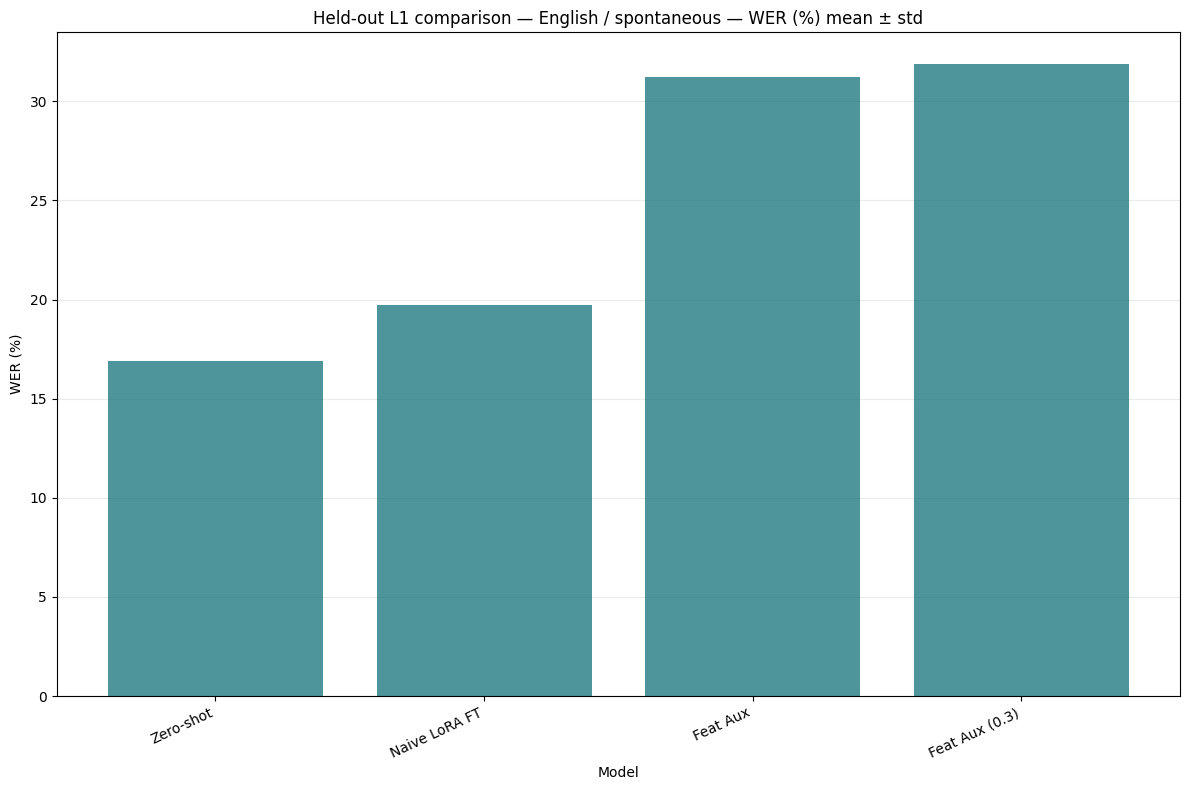

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

outdir = Path("output")
outdir.mkdir(exist_ok=True)

held_out_l1 = "English"
split = "spontaneous"
model_keys = [
    "baseline",
    "no_aux",
    # "no_aux_heldout_chinese",
    "feat_aux",
    # "feat_aux_heldout_chinese",
    "feat_aux0p3",

]

rows = []
for key in model_keys:
    if key not in results or split not in results[key]:
        continue

    df = results[key][split].copy()
    if "l1" not in df.columns:
        continue

    df = df[df["l1"] == held_out_l1]
    if len(df) == 0:
        continue

    row = {
        "model_key": key,
        "model": MODEL_KEYS.get(key, key),
        "n_utts": len(df),
        "n_speakers": df["speaker"].nunique() if "speaker" in df.columns else None,
        "wer_mean": corpus_wer(df) * 100,
    }

    if "utt_per" in df.columns:
        row["per_mean"] = df["utt_per"].mean()
        row["per_std"] = df["utt_per"].std()

    rows.append(row)

heldout_cmp = pd.DataFrame(rows).reset_index(drop=True)
heldout_cmp.to_csv(outdir / "heldout_l1_comparison.csv", index=False)

plot_df = heldout_cmp.copy()
plot_df["label"] = plot_df["model"] if "model" in plot_df.columns else plot_df["model_key"]

metrics = [("wer_mean", "WER (%)", "#01696f")]
# if "per_mean" in plot_df.columns and plot_df["per_mean"].notna().any():
#     metrics.append(("per_mean", "per_std", "PER", "#0b5177"))

fig, axes = plt.subplots(len(metrics), 1, figsize=(12, 8 * len(metrics)), sharex=True)
if len(metrics) == 1:
    axes = [axes]

x = range(len(plot_df))
for ax, (mean_col, title, color) in zip(axes, metrics):
    means = plot_df[mean_col].to_numpy()
    ax.bar(x, means, color=color, alpha=0.7, capsize=5)
    ax.set_ylabel(title)
    ax.set_title(f"Held-out L1 comparison — {held_out_l1} / {split} — {title} mean ± std")
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

axes[-1].set_xticks(list(x))
axes[-1].set_xticklabels(plot_df["label"], rotation=25, ha="right")
axes[-1].set_xlabel("Model")

fig.tight_layout()
fig.savefig(outdir / "heldout_l1_points_whiskers.png", dpi=200, bbox_inches="tight")
fig.show()
print(outdir / "heldout_l1_comparison.csv")
print(outdir / "heldout_l1_points_whiskers.png")

fmt = {
    c: "{:.3f}"
    for c in heldout_cmp.columns
    if c.startswith(("wer_", "per_"))
}


display(
    heldout_cmp.style
        .format(fmt)
        .set_caption(f"Held-out L1 comparison — {held_out_l1} / {split}")
)

In [13]:
import numpy as np
import pandas as pd

def align_for_sigtest(
    df_a: pd.DataFrame,
    df_b: pd.DataFrame,
    group_value: str | None = None,
    group_col: str = "l1",
    metric_col: str = "utt_wer",
) -> pd.DataFrame:
    a = df_a.copy()
    b = df_b.copy()

    if group_value is not None:
        a = a[a[group_col] == group_value].copy()
        b = b[b[group_col] == group_value].copy()

    cols_a = ["utterance_id", group_col, metric_col]
    cols_b = ["utterance_id", group_col, metric_col]

    merged = (
        a[cols_a]
        .rename(columns={metric_col: "score_a", group_col: f"{group_col}_a"})
        .merge(
            b[cols_b].rename(columns={metric_col: "score_b", group_col: f"{group_col}_b"}),
            on="utterance_id",
            how="inner",
        )
    )

    if group_value is None and f"{group_col}_a" in merged.columns:
        merged[group_col] = merged[f"{group_col}_a"]

    merged = merged.dropna(subset=["score_a", "score_b"]).copy()
    merged["diff"] = merged["score_a"] - merged["score_b"]   # positive => model B better
    return merged